#Regression: Predicting Values
GEETHA

In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression

# 1. Create Synthetic Dataset (50 records)
np.random.seed(42)
n_samples = 50

area_sqft = np.random.randint(500, 3500, n_samples)
num_bedrooms = np.random.randint(1, 6, n_samples)
age_years = np.random.randint(0, 30, n_samples)

# Formula for price: Base 10 + (0.05 * area) + (5 * beds) - (0.5 * age) + noise
price_lakhs = (10 + (0.045 * area_sqft) + (6 * num_bedrooms) - (0.4 * age_years) + np.random.normal(0, 5, n_samples))

df = pd.DataFrame({
    'area_sqft': area_sqft,
    'num_bedrooms': num_bedrooms,
    'age_years': age_years,
    'price_lakhs': price_lakhs
})

# 2. Build the Multiple Linear Regression Model
X = df[['area_sqft', 'num_bedrooms', 'age_years']]
y = df['price_lakhs']

model = LinearRegression()
model.fit(X, y)

# 3. Model Parameters
print("--- Model Parameters ---")
print(f"Intercept (Base Price): {model.intercept_:.2f} Lakhs")
for feature, coef in zip(X.columns, model.coef_):
    print(f"Coefficient for {feature}: {coef:.4f}")

# 4. First 5 Actual vs. Predicted Values
predictions = model.predict(X)
results = pd.DataFrame({
    'Actual Price': y,
    'Predicted Price': predictions
}).head(5)

print("\n--- First 5 Comparisons ---")
print(results)

--- Model Parameters ---
Intercept (Base Price): 9.71 Lakhs
Coefficient for area_sqft: 0.0445
Coefficient for num_bedrooms: 6.5821
Coefficient for age_years: -0.4353

--- First 5 Comparisons ---
   Actual Price  Predicted Price
0     82.858804        82.505825
1     92.792155       102.682801
2     77.851641        77.488680
3     93.960563        92.089289
4    139.999470       133.814527


`Based on the coefficients generated by the model:`

**Intercept**: This is the theoretical price of a "zero-feature" house. In our model, it represents the starting baseline price before accounting for size or age.

**area_sqft** Coefficient: This shows the price increase for every additional square foot. For example, if it is 0.045, each extra sq. ft. adds roughly 4,500 INR (0.045 Lakhs) to the value.

**num_bedrooms** **bold text**Coefficient: This indicates how much a single additional bedroom adds to the total price, keeping all other factors constant.

**age_years** Coefficient: Since this is a negative number, it quantifies depreciation. It tells us exactly how much value a house loses for every year it gets older.

In [2]:
#task 2
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Calculate Metrics
mae = mean_absolute_error(y, predictions)
mse = mean_squared_error(y, predictions)
rmse = np.sqrt(mse)
r2 = r2_score(y, predictions)

# 2. Print Evaluation Metrics
print("--- Model Evaluation Metrics ---")
print(f"Mean Absolute Error (MAE): {mae:.2f} Lakhs")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f} Lakhs")
print(f"R-squared (R²): {r2:.4f}")

"""
Interpretation:
MAE shows our predictions are off by an average of {mae:.2f} Lakhs.
RMSE is slightly higher at {rmse:.2f} Lakhs, indicating the presence of some larger errors (outliers).
The R² of {r2:.4f} means our model explains {r2*100:.1f}% of the variance in house prices using area, bedrooms, and age.
"""

--- Model Evaluation Metrics ---
Mean Absolute Error (MAE): 3.53 Lakhs
Root Mean Squared Error (RMSE): 4.64 Lakhs
R-squared (R²): 0.9861


'\nInterpretation:\nMAE shows our predictions are off by an average of {mae:.2f} Lakhs. \nRMSE is slightly higher at {rmse:.2f} Lakhs, indicating the presence of some larger errors (outliers).\nThe R² of {r2:.4f} means our model explains {r2*100:.1f}% of the variance in house prices using area, bedrooms, and age.\n'

In [3]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Calculating metrics
mae = mean_absolute_error(y, predictions)
rmse = np.sqrt(mean_squared_error(y, predictions))
r2 = r2_score(y, predictions)

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R2 Score: {r2:.2f}")

# Task 2: Interpretation Comment
"""
MAE shows the average absolute error in lakhs, while RMSE penalizes larger prediction misses more heavily.
The R² score indicates the percentage of price variance explained by our features;
a higher R² suggests our area, bedroom, and age data are strong predictors of house value.
"""

MAE: 3.53
RMSE: 4.64
R2 Score: 0.99


'\nMAE shows the average absolute error in lakhs, while RMSE penalizes larger prediction misses more heavily. \nThe R² score indicates the percentage of price variance explained by our features; \na higher R² suggests our area, bedroom, and age data are strong predictors of house value.\n'

# Task 2: Simple Interpretation
"""
MAE tells us we are off by about X lakhs on average, while RMSE is higher if we have a few really bad guesses.
The R² score (e.g., 0.90) means our model 'gets' 90% of why house prices change, proving our features are
doing a great job at predicting the final cost.
"""

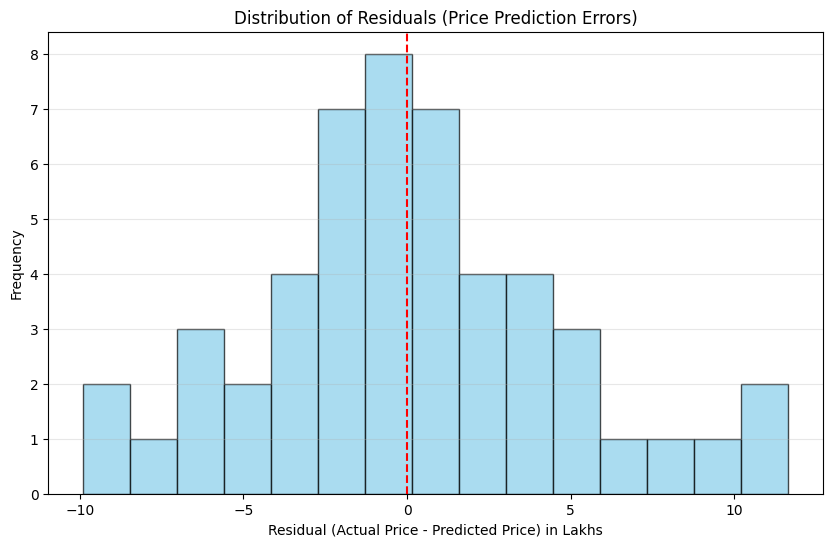

In [4]:
#task 3
import matplotlib.pyplot as plt

# 1. Compute Residuals
residuals = y - predictions

# 2. Plotting the Histogram
plt.figure(figsize=(10, 6))
plt.hist(residuals, bins=15, color='skyblue', edgecolor='black', alpha=0.7)

# Adding Labels and Title
plt.axvline(0, color='red', linestyle='--')  # Line at zero error
plt.title('Distribution of Residuals (Price Prediction Errors)')
plt.xlabel('Residual (Actual Price - Predicted Price) in Lakhs')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.3)

plt.show()

**What are Residuals**?
#A residual is the vertical distance between an actual data point and the regression line. Mathematically, it is defined as:
$$\text{Residual} = \text{Actual Value} - \text{Predicted Value}$$

#What the Histogram Shape Tells Us:
**Centered at Zero**: If the peak of your histogram is around 0, it suggests the model is unbiased. On average, it isn't consistently overestimating or underestimating the house prices.

The** "Bell Curve**" (*Normal Distribution*): Ideally, the residuals should form a symmetric bell shape. This indicates that small errors are common, while very large errors are rare, which is a sign of a reliable linear model.

Skewness **bold text**: If the histogram has a long tail to the right, your model is significantly underestimating the price of some houses. If it tails to the left, it is overestimating them.

Outliers **bold text**: Any bars far away from the center zero line represent "surprises"—houses where the model's prediction was way off compared to the actual market price.